<a href="https://colab.research.google.com/github/pri-2711/qiskit_codes/blob/main/Qiskit_code_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install qiskit_ibm_provider
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 154.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2cab0aaaadcf15e684136e5ea840fd1b7d98a93d3673d0c2f371552e228ce8da
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
import numpy as np

Deutsch-Jozsa Algorithm

In [20]:
#creating Input functions -> UNITARY FUNCTION
def dj_query(num_qubits):
    qc=QuantumCircuit(num_qubits+1)
    ''' 2 if condition : decides Constant/ Balanced function
    1st           2nd            result
    0 (no Xgate)  0 (continue)   BALANCED
    0 (no Xgate)  1 (return)     CONSTANT-0
    1 (Xgate)     0 (continue)   Complement BALANCED
    1 (Xgate)     1 (return)     CONSTANT-1'''

    if np.random.randint(0,2):
      qc.x(num_qubits)
    if np.random.randint(0,2):
      #Constant function is returned
      return qc

    ''' Balanced funciton:
    generating possibilities of combinations for result of f(x)'''

    on_states=np.random.choice(
        range(2**num_qubits), # total no.of samples for given no.of qubits
        2**num_qubits//2, # no.of samples to be chosen to change into f(x)=1 -> half other half -> f(x)=0
        replace=False
    )

    # to build a type of balanced function : additional gates in circuit
    def add_cx(qc,bit_string):
      for qubit, bit in enumerate(reversed(bit_string)):
        if bit=="1":
          qc.x(qubit)
      return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        bit_string = f"{state:0{num_qubits}b}"
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()
    return qc


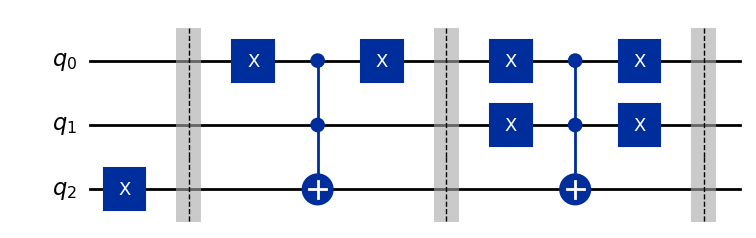

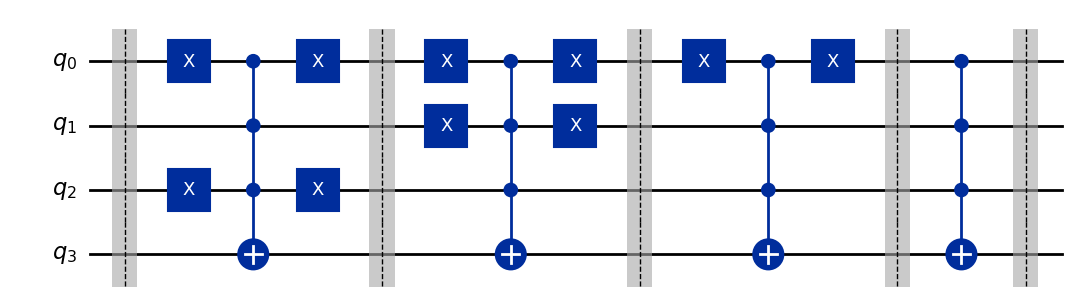

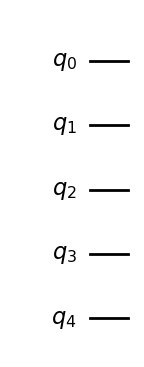

In [26]:
display(dj_query(2).draw(output="mpl"))
display(dj_query(3).draw(output="mpl"))
display(dj_query(4).draw(output="mpl"))

In [5]:
def compile_circuit(function: QuantumCircuit):
  n=function.num_qubits-1
  qc=QuantumCircuit(n+1,n)
  qc.x(n)
  qc.h(range(n+1)) # H gate to all Qubits
  qc.compose(function,inplace=True) # including Unitary funciton
  qc.barrier()
  qc.h(range(n)) # H to all qubits except Ancilla qubit
  qc.measure(range(n),range(n)) # collapsing system thru Measurement
  return qc

In [27]:
def dj_algorithm(function: QuantumCircuit):
  qc=compile_circuit(function)
  result=AerSimulator().run(qc,shots=1,memory=True).result()
  measurement=result.get_memory()
  ''' Before measurement:
  Phase kickback + interference modify the amplitude of |000...0⟩
  Constructive -> amplitude(|000...0⟩) = 1 -> Constant
  Destructive -> amplitude(|000...0⟩) = 0 -> Balanced

  After measurement: (like normal bit operation)
  If measured bitstring contains '1' -> Balanced
  Else (000...0) -> Constant '''
  if "1" in measurement[0]:
    return "balanced"
  return "constant"

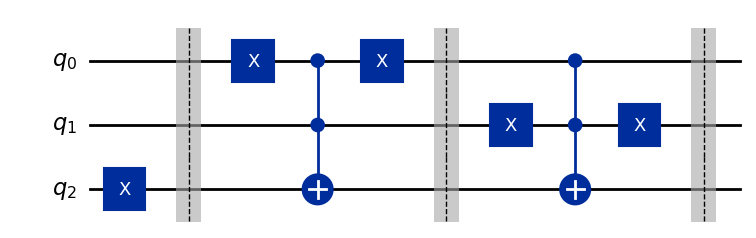

'balanced'

In [28]:
f1 = dj_query(2)
display(f1.draw("mpl"))
display(dj_algorithm(f1))

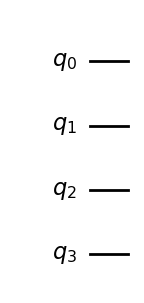

'constant'

In [29]:
f2 = dj_query(3)
display(f2.draw("mpl"))
display(dj_algorithm(f2))

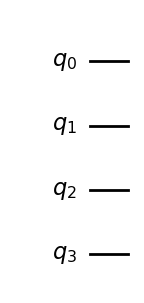

'constant'

In [30]:
f3 = dj_query(3)
display(f3.draw("mpl"))
display(dj_algorithm(f3))